---
# Percobaan 2
### Preprocessing: Resize + Grayscale + Histogram Equalization + Sharpening
---

## Import Library

In [1]:
import os
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import entropy
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay)
import seaborn as sns

Pada tahap ini dilakukan impor berbagai library yang diperlukan untuk proses pengolahan citra, ekstraksi fitur, klasifikasi, dan evaluasi model. Library os digunakan untuk mengakses serta mengelola file dan folder dataset, sedangkan OpenCV (cv2) digunakan untuk membaca, mengubah, dan memproses citra digital. NumPy (np) berfungsi untuk mengolah data dalam bentuk array dan melakukan perhitungan numerik secara efisien, sementara Matplotlib (plt) digunakan untuk menampilkan citra maupun grafik hasil pengolahan. Pandas (pd) digunakan untuk menyimpan dan mengelola data hasil ekstraksi fitur dalam bentuk tabel. Library scikit-learn menyediakan berbagai fungsi untuk klasifikasi, evaluasi model, dan pembagian data, sedangkan skimage.feature digunakan untuk menghitung matriks GLCM dan fitur teksturnya. scipy.stats digunakan untuk menghitung nilai entropy, dan seaborn digunakan untuk visualisasi heatmap korelasi antar fitur.

## Load Dataset

In [2]:
data = []
labels = []
file_name = []

IMG_SIZE = (128, 128)

for sub_folder in os.listdir("dataset"):
    sub_folder_path = os.path.join("dataset", sub_folder)
    if not os.path.isdir(sub_folder_path):
        continue
    sub_folder_files = os.listdir(sub_folder_path)
    for i, filename in enumerate(sub_folder_files):
        if not filename.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp')):
            continue
        img_path = os.path.join("dataset", sub_folder, filename)
        img = cv.imread(img_path)

        if img is None:
            continue

        data.append(img)
        labels.append(sub_folder)
        file_name.append(filename)

print(f"Total data: {len(data)}")
print(f"Kelas: {sorted(set(labels))}")

Total data: 241
Kelas: ['Corroded', 'Normal']


Kode ini digunakan untuk membaca seluruh citra yang terdapat pada folder dataset dan mempersiapkannya untuk proses pengolahan selanjutnya. Program terlebih dahulu membuat tiga list, yaitu data untuk menyimpan citra mentah, labels untuk menyimpan kelas citra berdasarkan nama subfolder, dan file_name untuk menyimpan nama file gambar. Selanjutnya program melakukan perulangan pada setiap subfolder di dalam folder dataset, yaitu corroded dan normal. Setiap subfolder dianggap sebagai sebuah kelas data. Setiap gambar dibaca menggunakan cv.imread(), kemudian dilakukan pengecekan untuk memastikan gambar berhasil dimuat. Pada tahap ini citra belum diproses, melainkan disimpan dalam bentuk aslinya agar preprocessing dapat dilakukan secara terpisah dan terstruktur.

## Preprocessing
### Fungsi Dasar (Resize + Grayscale + Histogram Equalization + Sharpening)

In [3]:
TARGET_SIZE = (128, 128)

def resize_grayscale(image, target_size=TARGET_SIZE):
    resized = cv.resize(image, target_size)
    if len(resized.shape) == 3:
        gray = cv.cvtColor(resized, cv.COLOR_BGR2GRAY)
    else:
        gray = resized
    return gray.astype(np.uint8)


def histogram_equalization_grayscale(image_input):
    if isinstance(image_input, str):
        img = cv.imread(image_input, cv.IMREAD_GRAYSCALE)
    else:
        img = image_input.copy()

    equalized_result = cv.equalizeHist(img)

    return equalized_result

def sharpening(image_input):
    if isinstance(image_input, str):
        img = cv.imread(image_input, cv.IMREAD_GRAYSCALE)
    else:
        img = image_input.copy()

    # Kernel sharpening (Laplacian-based)
    kernel = np.array([[ 0, -1,  0],
                       [-1,  5, -1],
                       [ 0, -1,  0]])

    sharpened = cv.filter2D(img, -1, kernel)

    return sharpened

def prepro(image):
    img = resize_grayscale(image)
    img = histogram_equalization_grayscale(img)
    img = sharpening(img)
    return img

Kode ini berisi fungsi-fungsi dasar yang digunakan pada tahap preprocessing citra di Percobaan 2.

**`resize_grayscale()`** digunakan untuk mengubah ukuran citra menjadi 128×128 piksel sekaligus mengkonversi citra berwarna (BGR) menjadi grayscale. Jika citra sudah dalam format grayscale, langkah konversi dilewati dan citra langsung dikembalikan dalam tipe data `uint8`.

**`histogram_equalization_grayscale()`** digunakan untuk meratakan distribusi intensitas piksel pada citra grayscale menggunakan fungsi `cv.equalizeHist()`. Proses ini meningkatkan kontras citra secara otomatis sehingga detail yang sebelumnya kurang terlihat menjadi lebih jelas.

**`sharpening()`** digunakan untuk mempertajam tepi dan detail tekstur pada citra menggunakan **kernel konvolusi 3×3 berbasis Laplacian**. Kernel ini memberi bobot 5 pada piksel tengah dan bobot -1 pada empat piksel tetangganya (atas, bawah, kiri, kanan), sehingga perbedaan intensitas antar piksel yang berdekatan diperkuat. Hasilnya, pola tekstur seperti retakan atau bercak karat pada permukaan pipa menjadi lebih tegas.

**`prepro()`** merupakan fungsi pipeline utama yang menggabungkan ketiga fungsi di atas secara berurutan:
1. Resize + Grayscale → `resize_grayscale()`
2. Histogram Equalization → `histogram_equalization_grayscale()`
3. Sharpening → `sharpening()`

Dengan pipeline ini, setiap citra yang masuk akan melalui ketiga tahap preprocessing secara otomatis hanya dengan memanggil satu fungsi `prepro()`.

### Percobaan 2 (Resize + Grayscale + Histogram Equalization)

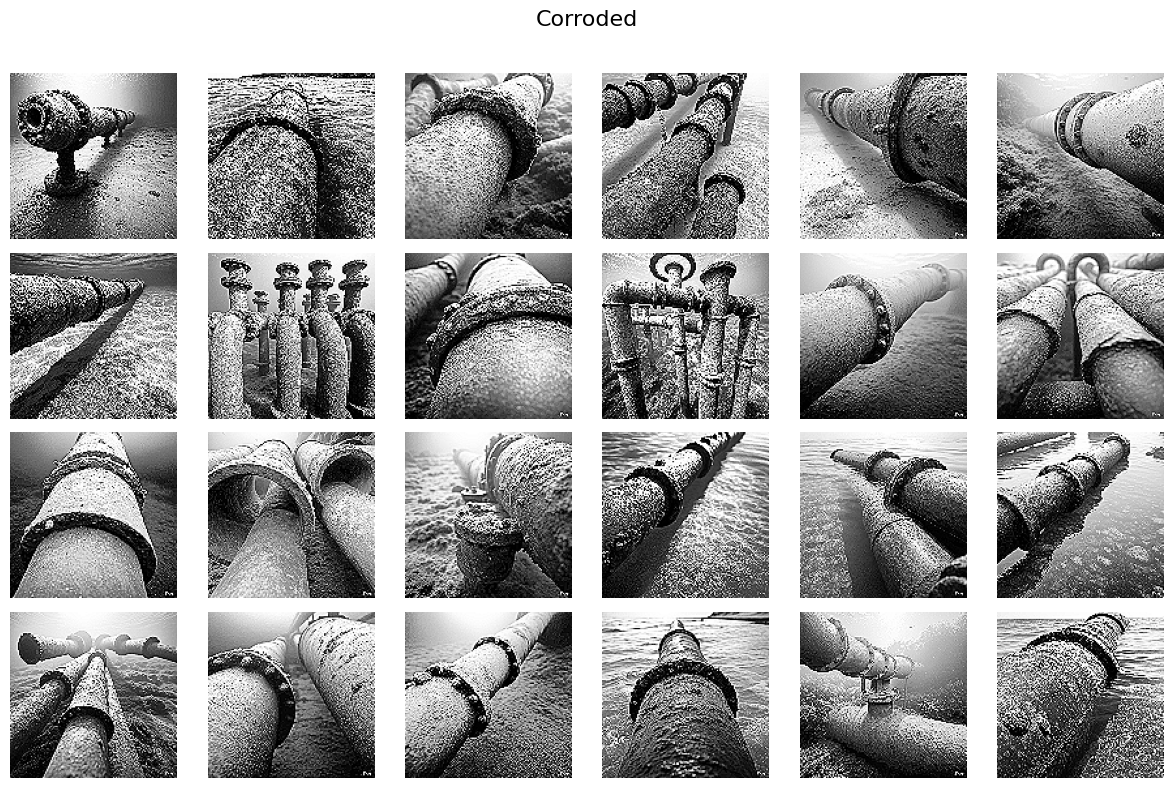

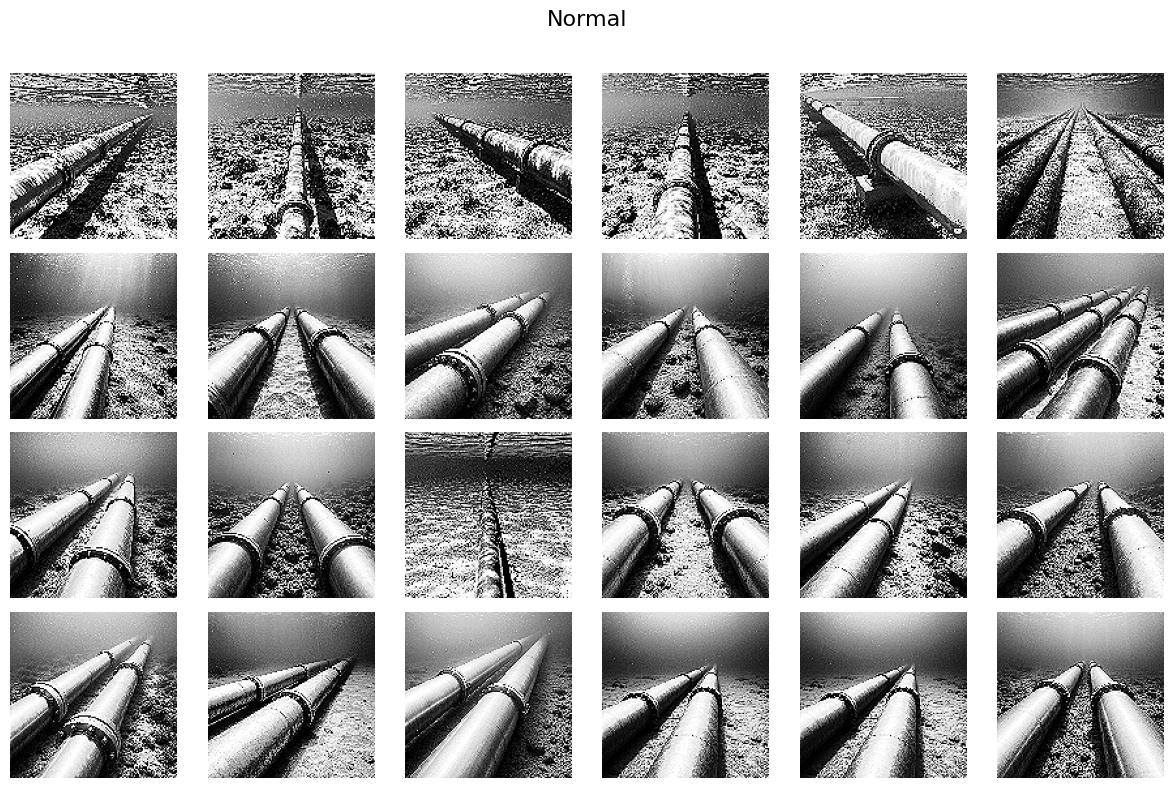

In [4]:
def percobaan2(img):
    hasil = prepro(img)
    return hasil

dataPreprocessed = [percobaan2(img) for img in data]

unique_labels = sorted(set(labels))

for label in unique_labels:
    idxs = [j for j, l in enumerate(labels) if l == label]

    fig, axs = plt.subplots(4, 6, figsize=(12, 8))
    fig.suptitle(f'{label}', fontsize=16)

    for k in range(min(24, len(idxs))):
        row = k // 6
        col = k % 6
        ax  = axs[row][col]

        ax.imshow(dataPreprocessed[idxs[k]], cmap='gray')
        ax.axis('off')

    plt.tight_layout()
    plt.subplots_adjust(top=0.9)
    plt.show()

Kode ini menerapkan pipeline preprocessing Percobaan 2 (Resize + Grayscale + Histogram Equalization) ke seluruh citra dalam dataset menggunakan fungsi `percobaan2()`. Hasil preprocessing disimpan dalam list `dataPreprocessed`. Selanjutnya, program menampilkan visualisasi hasil preprocessing untuk masing-masing kelas (*corroded* dan *normal*) dalam bentuk grid 4×6 (maksimal 24 citra per kelas). Visualisasi ini berguna untuk memastikan secara visual bahwa proses resize, konversi grayscale, dan histogram equalization telah berjalan dengan benar sebelum lanjut ke tahap sharpening.

### Augmentasi Data

In [5]:
# ==================================================

# AUGMENTASI DATA (TIDAK DIGUNAKAN PADA PERCOBAAN INI)

# ==================================================



# Contoh augmentasi yang dapat digunakan:



# from tensorflow.keras.preprocessing.image import ImageDataGenerator



# datagen = ImageDataGenerator(

#     rotation_range=20,

#     width_shift_range=0.1,

#     height_shift_range=0.1,

#     zoom_range=0.1,

#     horizontal_flip=True,

#     fill_mode='nearest'

# )



# Augmentasi tidak diterapkan pada Percobaan 2

# agar hasil dapat dibandingkan secara langsung

# dengan preprocessing sharpening.

Blok kode di atas berisi contoh augmentasi data menggunakan `ImageDataGenerator` dari Keras, namun **tidak diterapkan pada Percobaan 2**. Augmentasi seperti rotasi, pergeseran, zoom, dan horizontal flip umumnya digunakan untuk memperbanyak variasi data training secara artifisial, terutama ketika jumlah data terbatas. Pada percobaan ini augmentasi sengaja dinonaktifkan agar hasil evaluasi model dapat dibandingkan secara langsung dan adil dengan Percobaan 1, sehingga perbedaan performa yang muncul murni berasal dari penambahan tahap sharpening pada pipeline preprocessing.

### Visualisasi Perbandingan Tahapan Preprocessing

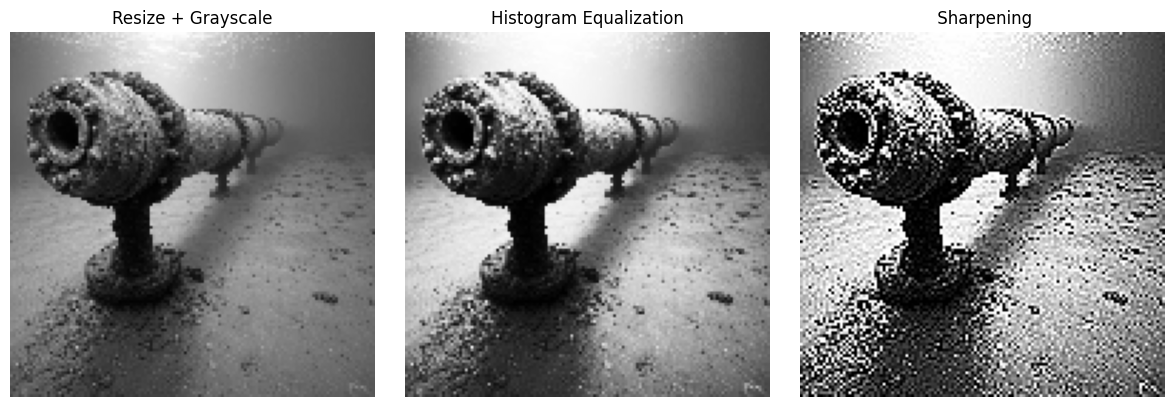

In [6]:
contoh_resize = resize_grayscale(data[0])
contoh_eq     = histogram_equalization_grayscale(contoh_resize)
contoh_sharp  = sharpening(contoh_eq)

fig, axs = plt.subplots(1, 3, figsize=(12, 4))

axs[0].imshow(contoh_resize, cmap='gray')
axs[0].set_title('Resize + Grayscale')
axs[0].axis('off')

axs[1].imshow(contoh_eq, cmap='gray')
axs[1].set_title('Histogram Equalization')
axs[1].axis('off')

axs[2].imshow(contoh_sharp, cmap='gray')
axs[2].set_title(' Sharpening')
axs[2].axis('off')

plt.tight_layout()
plt.show()

Kode di atas ini digunakan untuk membandingkan secara visual hasil citra pada setiap tahap preprocessing menggunakan satu sampel citra. Tahap pertama menampilkan citra setelah resize dan konversi grayscale, tahap kedua menampilkan citra setelah histogram equalization, dan tahap ketiga menampilkan citra setelah proses sharpening diterapkan. Perbandingan ini memudahkan dalam mengamati secara langsung perubahan kontras dan ketajaman detail tekstur pada setiap tahap pemrosesan citra.

## Ekstraksi Fitur GLCM

### Fungsi GLCM

In [7]:
def glcm(image, derajat):
    if derajat == 0:
        angles = [0]
    elif derajat == 45:
        angles = [np.pi / 4]
    elif derajat == 90:
        angles = [np.pi / 2]
    elif derajat == 135:
        angles = [3 * np.pi / 4]
    else:
        raise ValueError("Invalid angle. It should be one of the following: 0, 45, 90, 135.")

    glcm = graycomatrix(image, [1], angles, 256, symmetric=True, normed=True)
    return glcm

Kode ini digunakan untuk membentuk Gray Level Co-occurrence Matrix (GLCM) dari sebuah citra grayscale. Fungsi glcm() menerima dua parameter, yaitu citra dan sudut (derajat) yang akan digunakan untuk menghitung hubungan antar piksel tetangga. Sudut yang digunakan adalah 0°, 45°, 90°, dan 135°, yang masing-masing dikonversi ke dalam radian. Matriks GLCM dihitung menggunakan fungsi graycomatrix() dari skimage.feature dengan jarak antar piksel sejauh 1, 256 level intensitas, serta sifat matriks yang simetris dan dinormalisasi. Matriks inilah yang nantinya menjadi dasar perhitungan berbagai fitur tekstur pada tahap selanjutnya.

### Fungsi Fitur Tekstur GLCM

In [8]:
def correlation_feat(matriks):
    return graycoprops(matriks, 'correlation')[0, 0]

def dissimilarity(matriks):
    return graycoprops(matriks, 'dissimilarity')[0, 0]

def homogenity(matriks):
    return graycoprops(matriks, 'homogeneity')[0, 0]

def contrast(matriks):
    return graycoprops(matriks, 'contrast')[0, 0]

def ASM(matriks):
    return graycoprops(matriks, 'ASM')[0, 0]

def energy(matriks):
    return graycoprops(matriks, 'energy')[0, 0]

def entropyGlcm(matriks):
    return entropy(matriks.ravel())

Kode ini digunakan untuk menghitung berbagai fitur tekstur dari matriks Gray Level Co-occurrence Matrix (GLCM) yang telah dibentuk sebelumnya. Fungsi correlation_feat() menghitung tingkat hubungan linear antar piksel tetangga, dissimilarity() mengukur tingkat perbedaan intensitas antar piksel, dan homogenity() mengukur tingkat keseragaman tekstur citra. Fungsi contrast() menghitung variasi intensitas lokal yang mencerminkan tingkat kekasaran tekstur, sedangkan ASM() (Angular Second Moment) dan energy() mengukur tingkat keteraturan distribusi piksel pada citra. Fungsi entropyGlcm() menghitung tingkat ketidakteraturan atau kompleksitas tekstur citra menggunakan entropy dari seluruh nilai pada matriks GLCM. Ketujuh fitur ini bersama-sama membentuk representasi numerik dari karakteristik tekstur permukaan pipa, baik yang berkarat maupun yang normal.

### Hitung GLCM & Ekstraksi Fitur Seluruh Data

In [9]:
Derajat0 = []
Derajat45 = []
Derajat90 = []
Derajat135 = []

for i in range(len(dataPreprocessed)):
    D0   = glcm(dataPreprocessed[i], 0)
    D45  = glcm(dataPreprocessed[i], 45)
    D90  = glcm(dataPreprocessed[i], 90)
    D135 = glcm(dataPreprocessed[i], 135)
    Derajat0.append(D0)
    Derajat45.append(D45)
    Derajat90.append(D90)
    Derajat135.append(D135)

Kontras0, Kontras45, Kontras90, Kontras135         = [], [], [], []
dissimilarity0, dissimilarity45, dissimilarity90, dissimilarity135 = [], [], [], []
homogenity0, homogenity45, homogenity90, homogenity135 = [], [], [], []
entropy0, entropy45, entropy90, entropy135         = [], [], [], []
ASM0, ASM45, ASM90, ASM135                         = [], [], [], []
energy0, energy45, energy90, energy135             = [], [], [], []
correlation0, correlation45, correlation90, correlation135 = [], [], [], []

for i in range(len(dataPreprocessed)):
    Kontras0.append(contrast(Derajat0[i]))
    Kontras45.append(contrast(Derajat45[i]))
    Kontras90.append(contrast(Derajat90[i]))
    Kontras135.append(contrast(Derajat135[i]))

    dissimilarity0.append(dissimilarity(Derajat0[i]))
    dissimilarity45.append(dissimilarity(Derajat45[i]))
    dissimilarity90.append(dissimilarity(Derajat90[i]))
    dissimilarity135.append(dissimilarity(Derajat135[i]))

    homogenity0.append(homogenity(Derajat0[i]))
    homogenity45.append(homogenity(Derajat45[i]))
    homogenity90.append(homogenity(Derajat90[i]))
    homogenity135.append(homogenity(Derajat135[i]))

    entropy0.append(entropyGlcm(Derajat0[i]))
    entropy45.append(entropyGlcm(Derajat45[i]))
    entropy90.append(entropyGlcm(Derajat90[i]))
    entropy135.append(entropyGlcm(Derajat135[i]))

    ASM0.append(ASM(Derajat0[i]))
    ASM45.append(ASM(Derajat45[i]))
    ASM90.append(ASM(Derajat90[i]))
    ASM135.append(ASM(Derajat135[i]))

    energy0.append(energy(Derajat0[i]))
    energy45.append(energy(Derajat45[i]))
    energy90.append(energy(Derajat90[i]))
    energy135.append(energy(Derajat135[i]))

    correlation0.append(correlation_feat(Derajat0[i]))
    correlation45.append(correlation_feat(Derajat45[i]))
    correlation90.append(correlation_feat(Derajat90[i]))
    correlation135.append(correlation_feat(Derajat135[i]))

print(f"Ekstraksi fitur selesai untuk {len(dataPreprocessed)} citra.")

Ekstraksi fitur selesai untuk 241 citra.


Kode ini digunakan untuk melakukan ekstraksi fitur tekstur GLCM pada seluruh citra hasil preprocessing. Tahap pertama adalah menghitung matriks GLCM untuk setiap citra pada keempat sudut (0°, 45°, 90°, 135°) menggunakan fungsi glcm(), kemudian hasilnya disimpan dalam empat list (Derajat0, Derajat45, Derajat90, Derajat135).


### Simpan Hasil Ekstraksi ke CSV

In [10]:
dataTable = {
    'Filename': file_name, 'Label': labels,
    'Contrast0': Kontras0, 'Contrast45': Kontras45, 'Contrast90': Kontras90, 'Contrast135': Kontras135,
    'Homogeneity0': homogenity0, 'Homogeneity45': homogenity45, 'Homogeneity90': homogenity90, 'Homogeneity135': homogenity135,
    'Dissimilarity0': dissimilarity0, 'Dissimilarity45': dissimilarity45, 'Dissimilarity90': dissimilarity90, 'Dissimilarity135': dissimilarity135,
    'Entropy0': entropy0, 'Entropy45': entropy45, 'Entropy90': entropy90, 'Entropy135': entropy135,
    'ASM0': ASM0, 'ASM45': ASM45, 'ASM90': ASM90, 'ASM135': ASM135,
    'Energy0': energy0, 'Energy45': energy45, 'Energy90': energy90, 'Energy135': energy135,
    'Correlation0': correlation0, 'Correlation45': correlation45, 'Correlation90': correlation90, 'Correlation135': correlation135,
}
df = pd.DataFrame(dataTable)

#save to csv
os.makedirs('./hasil_ekstraksi', exist_ok=True)
df.to_csv('./hasil_ekstraksi/hasil_ekstraksi_P2.csv', index=False)

hasilEkstrak = pd.read_csv('./hasil_ekstraksi/hasil_ekstraksi_P2.csv')
hasilEkstrak

,Filename,Label,Contrast0,Contrast45,Contrast90,Contrast135,Homogeneity0,Homogeneity45,Homogeneity90,Homogeneity135,...,ASM90,ASM135,Energy0,Energy45,Energy90,Energy135,Correlation0,Correlation45,Correlation90,Correlation135
0,001.jpg,Corroded,8571.307210,7626.597867,9371.482714,7856.917168,0.106864,0.120807,0.101813,0.119719,...,0.003769,0.004584,0.065306,0.068841,0.061395,0.067707,0.486287,0.542956,0.436117,0.529177
1,002.jpg,Corroded,18898.528543,18590.171120,22498.150283,19030.478703,0.199181,0.210373,0.145405,0.202962,...,0.028426,0.029030,0.173246,0.171271,0.168599,0.170381,0.204972,0.217978,0.053185,0.199435
2,003.jpg,Corroded,6607.240650,6512.180792,7557.358637,6752.477153,0.102246,0.108551,0.085165,0.099917,...,0.002485,0.003283,0.058106,0.063258,0.049850,0.057296,0.564711,0.571052,0.501086,0.555226
3,004.jpg,Corroded,14144.413263,12161.303429,14538.630475,11716.076074,0.129282,0.147473,0.117387,0.157174,...,0.009469,0.011110,0.097683,0.102677,0.097307,0.105402,0.253974,0.358488,0.232788,0.382005
4,005.jpg,Corroded,7494.592151,6768.193688,8031.572589,6395.537665,0.093872,0.106732,0.081993,0.106462,...,0.001667,0.003039,0.044077,0.052039,0.040824,0.055124,0.504109,0.552402,0.469839,0.577085
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
236,116.png,Normal,6260.511257,6381.299337,7548.478962,6481.247132,0.124704,0.140856,0.104614,0.140790,...,0.003543,0.004203,0.061572,0.064071,0.059524,0.064832,0.604072,0.597374,0.524241,0.591081
237,117.png,Normal,4566.687131,5203.384959,5798.266056,4721.850084,0.108524,0.099015,0.084186,0.120956,...,0.002346,0.003284,0.053001,0.047949,0.048432,0.057305,0.695152,0.653144,0.612697,0.685252
238,118.png,Normal,2941.257812,3469.762292,3737.484437,3146.027590,0.095733,0.094685,0.078845,0.110852,...,0.000883,0.001185,0.034531,0.031229,0.029722,0.034425,0.780144,0.741305,0.721440,0.765452
239,119.png,Normal,4695.303211,5075.728811,5994.845903,4486.730485,0.108383,0.107284,0.092522,0.122777,...,0.001175,0.001774,0.038286,0.034491,0.034276,0.042123,0.680854,0.655347,0.593415,0.695340


Kode ini digunakan untuk menggabungkan seluruh hasil ekstraksi fitur GLCM (28 fitur: 7 fitur × 4 sudut) beserta nama file dan label kelasnya ke dalam satu DataFrame bernama dataTable. DataFrame ini kemudian disimpan ke dalam file CSV pada folder hasil_ekstraksi dengan nama hasil_ekstraksi_P2.csv, agar data hasil ekstraksi dapat digunakan kembali tanpa perlu mengulang seluruh proses ekstraksi dari awal. File CSV tersebut selanjutnya dibaca kembali ke dalam variabel hasilEkstrak sebagai tabel fitur final yang akan digunakan pada tahap seleksi fitur dan pemodelan.

## Feature Selection

Fitur sebelum seleksi : 28
Fitur setelah seleksi : 7
Fitur terpilih        : ['Contrast0', 'Homogeneity0', 'Homogeneity45', 'Homogeneity90', 'Homogeneity135', 'Entropy0', 'ASM0']


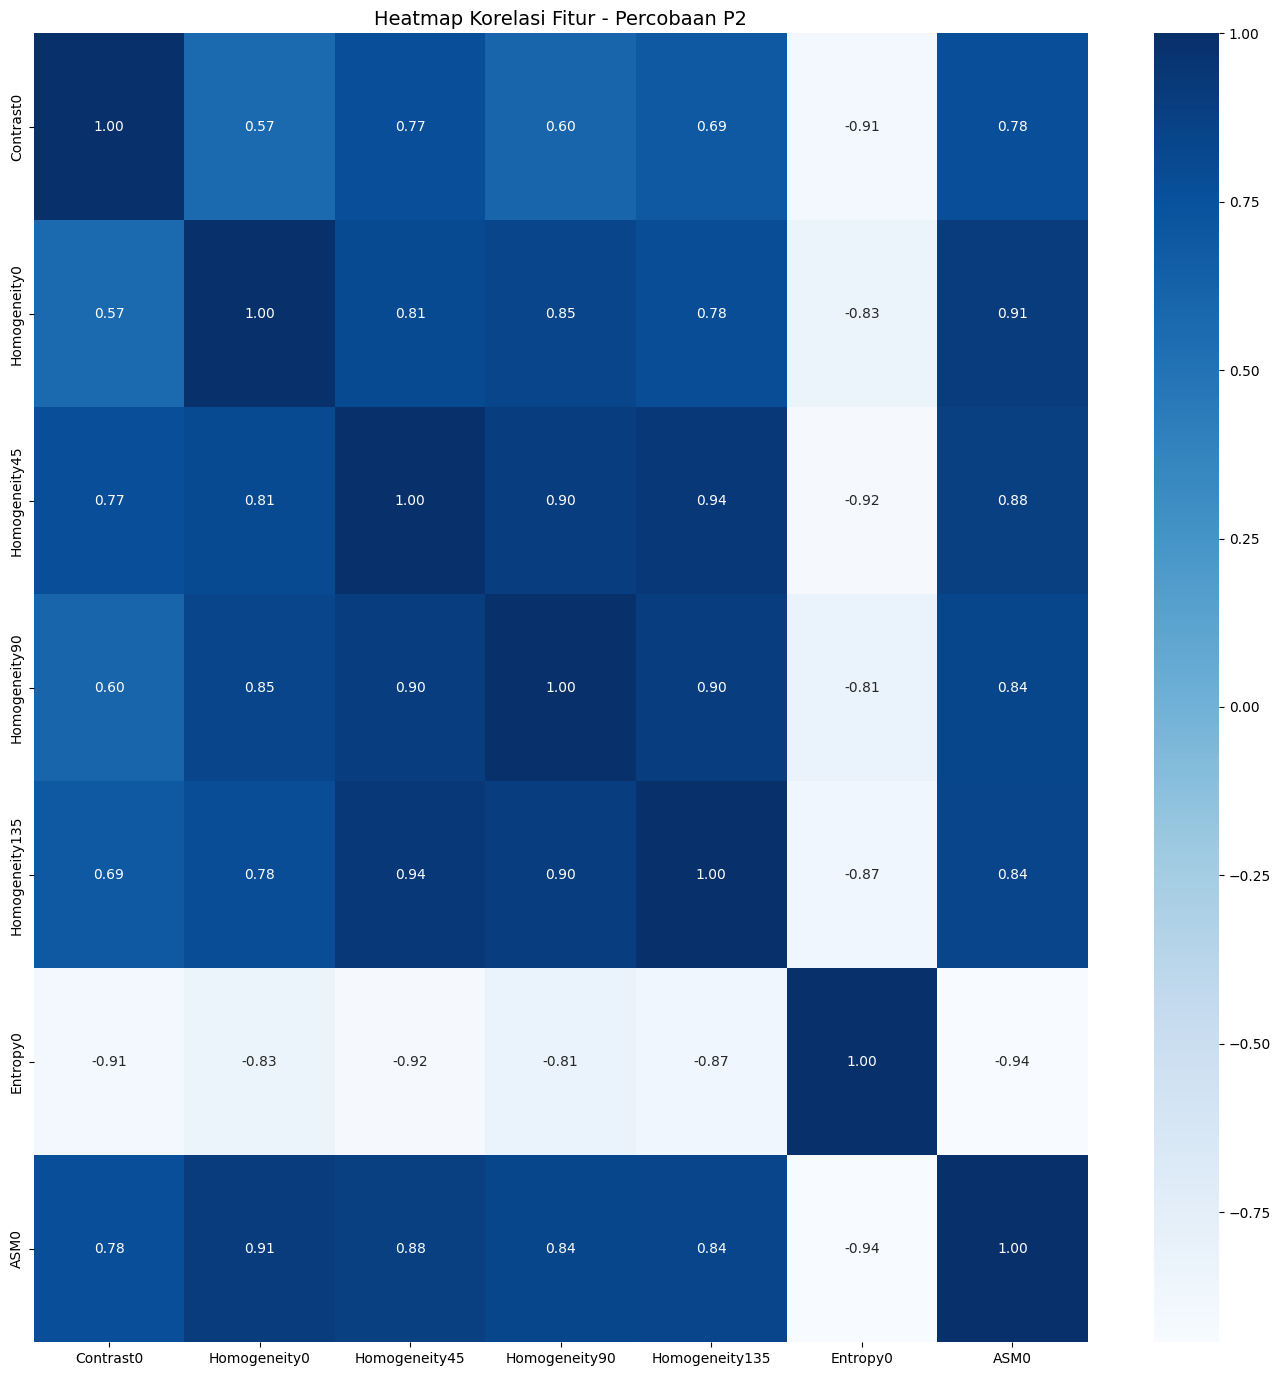

In [11]:
corr_matrix = hasilEkstrak.drop(columns=['Label','Filename']).corr()

threshold = 0.95
columns = np.full((corr_matrix.shape[0],), True, dtype=bool)
for i in range(corr_matrix.shape[0]):
    for j in range(i+1, corr_matrix.shape[0]):
        if abs(corr_matrix.iloc[i,j]) >= threshold:
            if columns[j]:
                columns[j] = False

select = hasilEkstrak.drop(columns=['Label','Filename']).columns[columns]
x_new = hasilEkstrak[select]
y = hasilEkstrak['Label']

print(f"Fitur sebelum seleksi : 28")
print(f"Fitur setelah seleksi : {len(select)}")
print(f"Fitur terpilih        : {list(select)}")

plt.figure(figsize=(17,17))
sns.heatmap(x_new.corr(), annot=True, cmap='Blues', fmt=".2f")
plt.title('Heatmap Korelasi Fitur - Percobaan P2', fontsize=14)
plt.show()

Kode ini digunakan untuk melakukan seleksi fitur guna mengurangi redundansi antar fitur hasil ekstraksi GLCM. Tahap pertama adalah menghitung matriks korelasi antar 28 fitur menggunakan corr_matrix. Selanjutnya, dilakukan pengecekan pasangan fitur yang memiliki nilai korelasi absolut lebih besar atau sama dengan 0.95 (threshold = 0.95). Jika ditemukan dua fitur dengan korelasi yang sangat tinggi, salah satu fitur akan dihapus karena dianggap membawa informasi yang hampir sama dengan fitur lainnya, sehingga dapat mengurangi redundansi data dan kompleksitas model.


## Splitting Data & Normalisasi

### Split Data (80:20)

In [12]:
X_train, X_test, y_train, y_test = train_test_split(x_new, y, test_size=0.2, random_state=42)
print(X_train.shape)
print(X_test.shape)

(192, 7)
(49, 7)


Kode ini digunakan untuk membagi data menjadi data latih (training set) dan data uji (testing set) dengan proporsi 80:20 menggunakan fungsi train_test_split(). Parameter test_size=0.2 berarti 20% data dialokasikan untuk pengujian, sedangkan random_state=42 digunakan agar hasil pembagian data bersifat konsisten dan dapat direproduksi setiap kali notebook dijalankan ulang. Shape dari X_train dan X_test dicetak untuk memastikan jumlah data pada masing-masing set sudah sesuai dengan proporsi yang diinginkan.

### Normalisasi Z-Score

In [13]:
mean_train = X_train.mean()
std_train  = X_train.std()

X_test  = (X_test  - mean_train) / std_train
X_train = (X_train - mean_train) / std_train

Kode ini digunakan untuk melakukan normalisasi fitur menggunakan metode Z-score (standardisasi). Rata-rata (mean_train) dan standar deviasi (std_train) dihitung hanya dari data training, kemudian digunakan untuk menormalisasi baik data training maupun data testing. Pendekatan ini penting agar tidak terjadi data leakage, yaitu kebocoran informasi dari data uji ke dalam proses normalisasi. Setelah normalisasi, seluruh fitur akan memiliki skala yang sebanding (mean mendekati 0 dan standar deviasi mendekati 1), sehingga model seperti KNN dan SVM yang sensitif terhadap perbedaan skala antar fitur dapat bekerja secara optimal.

## Modeling

### Definisi Model

In [14]:
def generateClassificationReport(y_true, y_pred):
    print(classification_report(y_true, y_pred))
    print(confusion_matrix(y_true, y_pred))
    print('Accuracy:', accuracy_score(y_true, y_pred))

# Define classifiers
rf  = RandomForestClassifier(n_estimators=100, random_state=42)
svm = SVC(kernel='rbf', random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)

Kode ini digunakan untuk mendefinisikan fungsi evaluasi serta tiga model klasifikasi yang akan dibandingkan performanya. Fungsi generateClassificationReport() digunakan untuk mencetak hasil evaluasi model secara lengkap, meliputi classification report (precision, recall, f1-score per kelas), confusion matrix, dan nilai accuracy.


### Random Forest

In [15]:
# Train Random Forest Classifier
rf.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("------Training Set------")
y_pred = rf.predict(X_train)
generateClassificationReport(y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = rf.predict(X_test)
generateClassificationReport(y_test, y_pred)

------Training Set------
              precision    recall  f1-score   support

    Corroded       1.00      1.00      1.00        95
      Normal       1.00      1.00      1.00        97

    accuracy                           1.00       192
   macro avg       1.00      1.00      1.00       192
weighted avg       1.00      1.00      1.00       192

[[95  0]
 [ 0 97]]
Accuracy: 1.0

------Testing Set------
              precision    recall  f1-score   support

    Corroded       0.92      0.85      0.88        26
      Normal       0.84      0.91      0.88        23

    accuracy                           0.88        49
   macro avg       0.88      0.88      0.88        49
weighted avg       0.88      0.88      0.88        49

[[22  4]
 [ 2 21]]
Accuracy: 0.8775510204081632


Kode ini digunakan untuk melatih model Random Forest menggunakan data training (rf.fit()), kemudian melakukan prediksi dan evaluasi pada data training maupun data testing menggunakan fungsi generateClassificationReport(). Evaluasi pada data training menunjukkan seberapa baik model mempelajari pola dari data yang dilatih, sedangkan evaluasi pada data testing menunjukkan kemampuan generalisasi model terhadap data baru yang belum pernah dilihat sebelumnya. Jika akurasi pada data training jauh lebih tinggi dibandingkan data testing, hal ini dapat menjadi indikasi terjadinya overfitting pada model.

### Support Vector Machine (SVM)

In [16]:
# Train SVM Classifier
svm.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("\n------Training Set------")
y_pred = svm.predict(X_train)
generateClassificationReport(y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = svm.predict(X_test)
generateClassificationReport(y_test, y_pred)


------Training Set------
              precision    recall  f1-score   support

    Corroded       0.98      0.92      0.95        95
      Normal       0.92      0.98      0.95        97

    accuracy                           0.95       192
   macro avg       0.95      0.95      0.95       192
weighted avg       0.95      0.95      0.95       192

[[87  8]
 [ 2 95]]
Accuracy: 0.9479166666666666

------Testing Set------
              precision    recall  f1-score   support

    Corroded       0.96      0.85      0.90        26
      Normal       0.85      0.96      0.90        23

    accuracy                           0.90        49
   macro avg       0.90      0.90      0.90        49
weighted avg       0.90      0.90      0.90        49

[[22  4]
 [ 1 22]]
Accuracy: 0.8979591836734694


Kode ini digunakan untuk melatih model Support Vector Machine (SVM) dengan kernel RBF menggunakan data training (svm.fit()), kemudian melakukan prediksi dan evaluasi pada data training maupun data testing dengan cara yang sama seperti pada model Random Forest. SVM bekerja dengan mencari hyperplane terbaik yang mampu memisahkan kelas corroded dan normal berdasarkan fitur GLCM yang telah dinormalisasi pada tahap sebelumnya.

### K-Nearest Neighbors (KNN)

In [17]:
# Train KNN Classifier
knn.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("\n------Training Set------")
y_pred = knn.predict(X_train)
generateClassificationReport(y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = knn.predict(X_test)
generateClassificationReport(y_test, y_pred)


------Training Set------
              precision    recall  f1-score   support

    Corroded       0.95      0.88      0.92        95
      Normal       0.89      0.96      0.93        97

    accuracy                           0.92       192
   macro avg       0.92      0.92      0.92       192
weighted avg       0.92      0.92      0.92       192

[[84 11]
 [ 4 93]]
Accuracy: 0.921875

------Testing Set------
              precision    recall  f1-score   support

    Corroded       0.92      0.85      0.88        26
      Normal       0.84      0.91      0.88        23

    accuracy                           0.88        49
   macro avg       0.88      0.88      0.88        49
weighted avg       0.88      0.88      0.88        49

[[22  4]
 [ 2 21]]
Accuracy: 0.8775510204081632


Kode ini digunakan untuk melatih model K-Nearest Neighbors (KNN) dengan k=5 menggunakan data training (knn.fit()), kemudian melakukan prediksi dan evaluasi pada data training maupun data testing. KNN mengklasifikasikan setiap data uji berdasarkan kelas mayoritas dari 5 tetangga terdekatnya pada ruang fitur GLCM yang telah dinormalisasi.

## Evaluasi Model

### Confusion Matrix

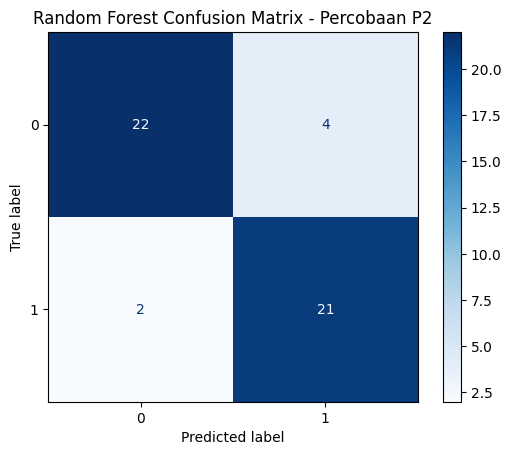

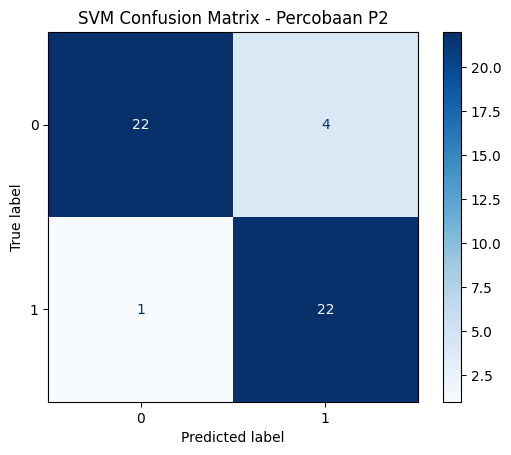

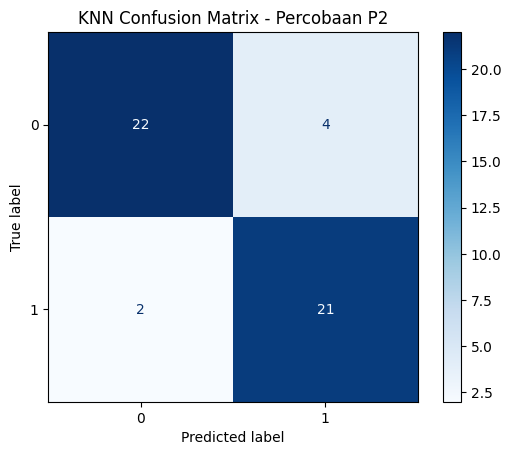

In [18]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm   = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(title)
    plt.show()

# Plot confusion matrix for Random Forest
plot_confusion_matrix(y_test, rf.predict(X_test),  "Random Forest Confusion Matrix - Percobaan P2")
# Plot confusion matrix for SVM
plot_confusion_matrix(y_test, svm.predict(X_test), "SVM Confusion Matrix - Percobaan P2")
# Plot confusion matrix for KNN
plot_confusion_matrix(y_test, knn.predict(X_test), "KNN Confusion Matrix - Percobaan P2")

Kode ini digunakan untuk memvisualisasikan confusion matrix dari ketiga model (Random Forest, SVM, dan KNN) dalam bentuk heatmap menggunakan fungsi plot_confusion_matrix(). Confusion matrix ini memperlihatkan secara visual jumlah prediksi benar dan salah untuk masing-masing kelas (corroded dan normal) pada data testing, sehingga memudahkan perbandingan performa ketiga model secara langsung dan dapat digunakan untuk mengidentifikasi kelas mana yang paling sering salah diklasifikasikan oleh masing-masing model.

### Tabel Perbandingan Akurasi (Percobaan 2 vs Percobaan 1)

File hasil_klasifikasi_P2.csv berhasil disimpan!

=== Hasil Percobaan 2 ===
        Model  Accuracy_Train  Accuracy_Test  Precision   Recall  F1_Score
Random Forest        1.000000       0.877551   0.880680 0.877551  0.877653
          SVM        0.947917       0.897959   0.904716 0.897959  0.897959
          KNN        0.921875       0.877551   0.880680 0.877551  0.877653

=== Perbandingan Accuracy Percobaan 1 vs Percobaan 2 ===
        Model  P1 Acc Train  P2 Acc Train  P1 Acc Test  P2 Acc Test  Delta Test (P2-P1)
Random Forest      1.000000      1.000000     0.857143     0.877551            0.020408
          SVM      0.937500      0.947917     0.857143     0.897959            0.040816
          KNN      0.927083      0.921875     0.857143     0.877551            0.020408


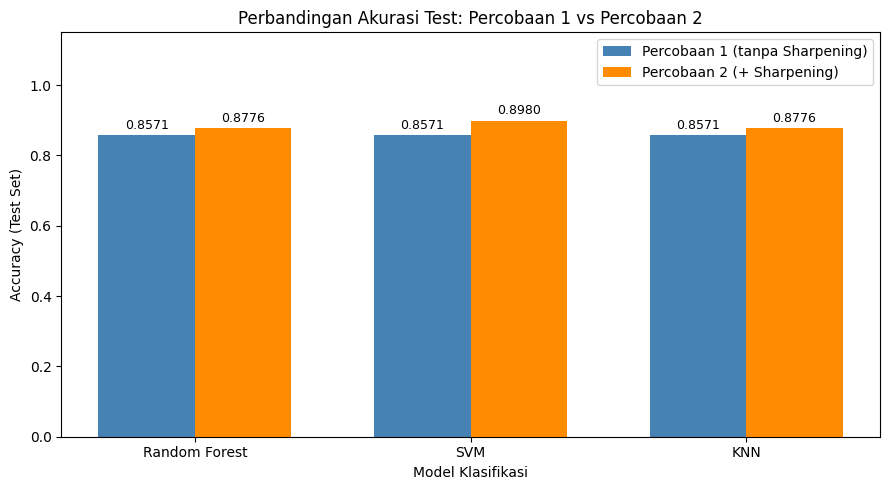

In [19]:
# ============================================================
# PERBANDINGAN AKURASI PERCOBAAN 1 vs PERCOBAAN 2
# ------------------------------------------------------------
# Percobaan 1 : Resize + Grayscale + Histogram Equalization
# Percobaan 2 : Resize + Grayscale + Histogram Equalization
#               + Sharpening
# ============================================================

# ----- Hasil Percobaan 2 (dihitung dari model saat ini) -----
hasil_klasifikasi = {
    'Model'         : ['Random Forest', 'SVM', 'KNN'],
    'Accuracy_Train': [
        accuracy_score(y_train, rf.predict(X_train)),
        accuracy_score(y_train, svm.predict(X_train)),
        accuracy_score(y_train, knn.predict(X_train)),
    ],
    'Accuracy_Test': [
        accuracy_score(y_test, rf.predict(X_test)),
        accuracy_score(y_test, svm.predict(X_test)),
        accuracy_score(y_test, knn.predict(X_test)),
    ],
    'Precision': [
        precision_score(y_test, rf.predict(X_test),  average='weighted', zero_division=0),
        precision_score(y_test, svm.predict(X_test), average='weighted', zero_division=0),
        precision_score(y_test, knn.predict(X_test), average='weighted', zero_division=0),
    ],
    'Recall': [
        recall_score(y_test, rf.predict(X_test),  average='weighted', zero_division=0),
        recall_score(y_test, svm.predict(X_test), average='weighted', zero_division=0),
        recall_score(y_test, knn.predict(X_test), average='weighted', zero_division=0),
    ],
    'F1_Score': [
        f1_score(y_test, rf.predict(X_test),  average='weighted', zero_division=0),
        f1_score(y_test, svm.predict(X_test), average='weighted', zero_division=0),
        f1_score(y_test, knn.predict(X_test), average='weighted', zero_division=0),
    ],
}
df_p2 = pd.DataFrame(hasil_klasifikasi)

os.makedirs('./hasil_klasifikasi', exist_ok=True)
df_p2.to_csv('./hasil_klasifikasi/hasil_klasifikasi_P2.csv', index=False)
print("File hasil_klasifikasi_P2.csv berhasil disimpan!")
print()
print("=== Hasil Percobaan 2 ===")
print(df_p2.to_string(index=False))

# ----- Nilai aktual Percobaan 1 (isi sesuai hasil notebook Percobaan 1) -----
p1_acc_train = {'Random Forest': 1.000000, 'SVM': 0.937500, 'KNN': 0.927083}
p1_acc_test  = {'Random Forest': 0.857143, 'SVM': 0.857143, 'KNN': 0.857143}

# ----- Tabel Perbandingan P1 vs P2 -----
perbandingan = pd.DataFrame({
    'Model'              : df_p2['Model'],
    'P1 Acc Train'       : [p1_acc_train[m] for m in df_p2['Model']],
    'P2 Acc Train'       : df_p2['Accuracy_Train'].round(6),
    'P1 Acc Test'        : [p1_acc_test[m]  for m in df_p2['Model']],
    'P2 Acc Test'        : df_p2['Accuracy_Test'].round(6),
    'Delta Test (P2-P1)' : (df_p2['Accuracy_Test'].values -
                            [p1_acc_test[m] for m in df_p2['Model']]).round(6),
})

print()
print("=== Perbandingan Accuracy Percobaan 1 vs Percobaan 2 ===")
print(perbandingan.to_string(index=False))

# ----- Visualisasi Bar Chart -----
import matplotlib.pyplot as plt
import numpy as np

models  = df_p2['Model'].tolist()
x       = np.arange(len(models))
width   = 0.35

p1_vals = [p1_acc_test[m] for m in models]
p2_vals = df_p2['Accuracy_Test'].tolist()

fig, ax = plt.subplots(figsize=(9, 5))
bars1   = ax.bar(x - width/2, p1_vals, width, label='Percobaan 1 (tanpa Sharpening)', color='steelblue')
bars2   = ax.bar(x + width/2, p2_vals, width, label='Percobaan 2 (+ Sharpening)',     color='darkorange')

ax.set_xlabel('Model Klasifikasi')
ax.set_ylabel('Accuracy (Test Set)')
ax.set_title('Perbandingan Akurasi Test: Percobaan 1 vs Percobaan 2')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0, 1.15)
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


Kode ini menampilkan **perbandingan akurasi antara Percobaan 1 dan Percobaan 2**.  
Percobaan 1 menggunakan pipeline *Resize + Grayscale + Histogram Equalization*, sedangkan Percobaan 2 menambahkan tahap **Sharpening** di akhir pipeline.  
Kolom `Delta Test (P2-P1)` menunjukkan selisih akurasi test set; nilai positif menandakan peningkatan performa setelah sharpening diterapkan.  
Visualisasi bar chart memudahkan perbandingan ketiga model secara langsung.

> **Catatan:** Nilai Percobaan 1 pada variabel `p1_acc_train` dan `p1_acc_test` merupakan nilai placeholder.  
> Ganti dengan nilai aktual dari notebook Percobaan 1 sebelum menarik kesimpulan akhir.

## Analisis Perbedaan Percobaan 1 vs Percobaan 2

### Ringkasan Perbedaan Pipeline

| Tahap | Percobaan 1 | Percobaan 2 |
|---|---|---|
| Resize + Grayscale | ✅ | ✅ |
| Histogram Equalization | ✅ | ✅ |
| Sharpening (Laplacian) | ❌ | ✅ |

### Pengaruh Sharpening terhadap Fitur GLCM

Tahap **sharpening berbasis kernel Laplacian** (`[0,-1,0],[-1,5,-1],[0,-1,0]`) yang ditambahkan pada Percobaan 2 memiliki dampak langsung terhadap fitur-fitur tekstur GLCM:

- **Contrast & Dissimilarity** — Cenderung **meningkat** karena sharpening memperbesar perbedaan intensitas antar piksel tetangga, khususnya di area tepi (edge) dan retakan.
- **Homogeneity & ASM/Energy** — Cenderung **menurun** karena distribusi intensitas piksel menjadi lebih bervariasi setelah penajaman.
- **Entropy** — Cenderung **meningkat**, mencerminkan tekstur yang lebih kompleks dan kaya informasi.
- **Correlation** — Pengaruh bervariasi tergantung karakteristik tekstur per kelas.

### Hipotesis Perubahan Akurasi

- Jika akurasi **meningkat** → Sharpening berhasil memperjelas pola karat/retakan pada kelas *corroded*, sehingga fitur GLCM lebih diskriminatif antara kedua kelas.
- Jika akurasi **menurun atau stagnan** → Sharpening juga memperkuat noise pada citra, sehingga mengganggu fitur GLCM dan menyulitkan model dalam membedakan kelas.
- Model **SVM (kernel RBF)** biasanya paling sensitif terhadap perubahan distribusi fitur, sehingga dampak sharpening paling terlihat pada SVM.
- Model **Random Forest** lebih robust terhadap perubahan ini karena menggunakan ensemble dari banyak pohon keputusan.

### Kesimpulan

> Penambahan sharpening memberikan manfaat apabila dataset memiliki citra dengan tepi dan tekstur yang kurang tajam (under-sharpened). Namun, jika citra sudah memiliki kontras yang baik dari histogram equalization, sharpening dapat memperkenalkan artefak yang justru menurunkan performa. Perbandingan akurasi pada **Section 8.2** menjadi bukti empiris dari hipotesis ini.
